In order to evaluate the UIs generated by Delineo, we use the SBERT metric.

Common metrics like Clip, Blip or FID are trained on broader datasets, and do not work well with the context of user interfaces. 

The approach used in this project, is to use the same model that generated the captions for the ControlNet training, with a similar prompt to generate a caption for the inferred UI.

This way we calculate the cosine similarity between the user original prompt with the generated caption.


After running experiments of negative sampling, It was noticed the SBERT metric would return values up to 0.5 for non-matching pairs, possibly related to very specific domain vocabulary with UI components and terminology.

Therefore, the following normalization was applied to this evaluation, setting an empirical lower and upper bound derived from statistical analysis on the experiments results. (view src/experiments/sbert/svert_eval.ipynb)

$$S_{norm} = \min\left(1, \max\left(0, \frac{S_{obs} - \tau_{min}}{\tau_{max} - \tau_{min}}\right)\right)$$

In [ ]:
import os
import json
import pandas as pd
from pathlib import Path
from sentence_transformers import SentenceTransformer, util
from tqdm.notebook import tqdm

EXPERIMENT_DIR = "./best_results"
GENERATED_JSONL_PATH = os.path.join(EXPERIMENT_DIR, "captions.jsonl")
GROUND_TRUTH_JSONL_PATH = "../ui_validation_captions.jsonl"
OUTPUT_CSV_PATH = os.path.join(EXPERIMENT_DIR, "sbert_evaluation_results.csv")
SBERT_MODEL_NAME = 'all-MiniLM-L6-v2'

T_MIN = 0.46
T_MAX = 0.81

In [37]:
def normalize_score(s_obs: float, t_min: float, t_max: float) -> float:
    val = (s_obs - t_min) / (t_max - t_min)
    return max(0.0, min(1.0, val))

def load_ground_truth(filepath: str) -> dict:
    """Carrega as captions originais como baseline."""
    gt_dict = {}
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                data = json.loads(line.strip())
                # Usa o stem do filename como chave (ex: Rico_2349_output.png -> Rico_2349_output)
                sample_id = Path(data["filename"]).stem 
                gt_dict[sample_id] = data["caption"]
    return gt_dict

def load_generated_captions(filepath: str) -> dict:
    """Carrega as captions geradas pela API do Gemini."""
    gen_dict = {}
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                data = json.loads(line.strip())
                sample_id = data["sample_id"]
                gen_dict[sample_id] = data["captions"]
    return gen_dict

In [38]:
if not os.path.exists(GENERATED_JSONL_PATH):
        raise FileNotFoundError(f"ERRO FATAL: Arquivo não encontrado em {GENERATED_JSONL_PATH}. Certifique-se de que a extração de captions foi concluída.")

if not os.path.exists(GROUND_TRUTH_JSONL_PATH):
    raise FileNotFoundError(f"ERRO FATAL: Arquivo Ground Truth não encontrado em {GROUND_TRUTH_JSONL_PATH}.")

print(f"[*] Carregando modelo SBERT: {SBERT_MODEL_NAME}...")
model = SentenceTransformer(SBERT_MODEL_NAME)

print("[*] Carregando datasets...")
gt_data = load_ground_truth(GROUND_TRUTH_JSONL_PATH)
gen_data = load_generated_captions(GENERATED_JSONL_PATH)
print("[*] Carregamento concluido")

[*] Carregando modelo SBERT: all-MiniLM-L6-v2...


[*] Carregando datasets...
[*] Carregamento concluido


In [39]:
records = []

# 3. Processamento e Cálculo SBERT
for sample_id, gen_captions_list in tqdm(gen_data.items(), desc="Calculando Similaridade"):
    if sample_id not in gt_data:
        print(f"[Aviso] Sample {sample_id} não encontrado no Ground Truth. Pulando...")
        continue
        
    gt_caption = gt_data[sample_id]
    gt_embedding = model.encode(gt_caption, convert_to_tensor=True)
    
    # Inicia o registro da linha com o ID da amostra
    row_data = {"sample_id": sample_id}
    
    # Calcula para cada seed
    for item in gen_captions_list:
        seed_val = item["seed"]
        gen_caption = item["caption"]
        
        # Codifica a caption gerada e calcula similaridade do cosseno bruta
        gen_embedding = model.encode(gen_caption, convert_to_tensor=True)
        s_obs = util.cos_sim(gt_embedding, gen_embedding).item()
        
        # Aplica a fórmula do seu TCC
        s_norm = normalize_score(s_obs, T_MIN, T_MAX)
        
        # Adiciona ao dicionário da linha (ex: "seed_42": 0.87)
        row_data[f"seed_{seed_val}"] = round(s_norm, 4)
        
    records.append(row_data)

Calculando Similaridade:   0%|          | 0/44 [00:00<?, ?it/s]

In [40]:
print("[*] Consolidando estatísticas globais...")
df = pd.DataFrame(records)
df.set_index("sample_id", inplace=True)

# Isolar as colunas de seed
seed_cols = [c for c in df.columns if str(c).startswith("seed_")]

# 1. Empilhar todas as colunas de seed em uma única Série (440 valores)
all_tests = df[seed_cols].stack()

# 2. Calcular as métricas globais em cima dos 440 testes reais
global_min = all_tests.min()
global_max = all_tests.max()
global_mean = all_tests.mean()
global_median = all_tests.median()
global_std = all_tests.std()

global_p10 = all_tests.quantile(0.1)
global_p25 = all_tests.quantile(0.25)
global_p75 = all_tests.quantile(0.75)
global_p90 = all_tests.quantile(0.9)

# 4. Exibição no Console
print("\n" + "="*55)
print(" RESUMO ESTATÍSTICO GLOBAL DA AVALIAÇÃO")
print("="*55)
print(f"Total de Testes (Inferências): {len(all_tests)}")
print(f"Média Global:                  {global_mean:.4f}")
print(f"Desvio Padrão Global:          {global_std:.4f}")
print("-" * 55)
print(f"P10:                           {global_p10:.4f}")
print(f"P25:                           {global_p25:.4f}")
print(f"Mediana Global (P50):          {global_median:.4f}")
print(f"P75:                           {global_p75:.4f}")
print(f"P90:                           {global_p90:.4f}")
print("="*55)

[*] Consolidando estatísticas globais...

 RESUMO ESTATÍSTICO GLOBAL DA AVALIAÇÃO
Total de Testes (Inferências): 440
Média Global:                  0.6181
Desvio Padrão Global:          0.4021
-------------------------------------------------------
P10:                           0.0000
P25:                           0.0000
Mediana Global (P50):          0.7928
P75:                           0.9843
P90:                           1.0000


[*] Gráfico salvo com sucesso em: validation_histogram.tiff


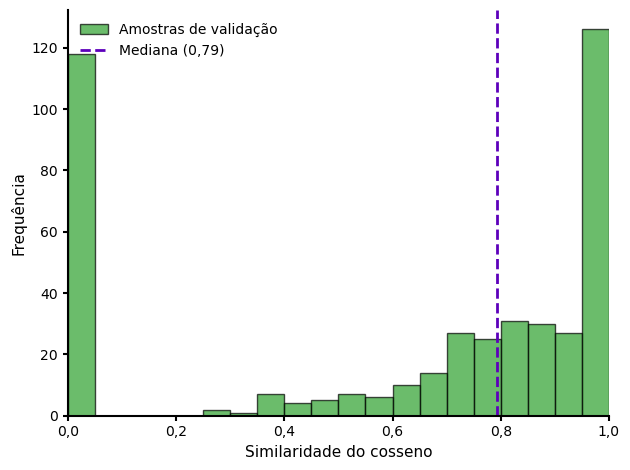

In [60]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter

# --- Considerando que 'all_tests', 'global_median' e 'global_p10' já foram calculados ---

pesos = np.ones(len(all_tests)) / len(all_tests)

def formata_eixo(x, _):
    """Mantém 1 casa decimal no eixo X e troca ponto por vírgula."""
    return f"{x:.1f}".replace(".", ",")

# Plotagem do histograma usando os 440 testes globais
counts, bins, patches = plt.hist(
    all_tests, 
    bins=20,
    alpha=0.7, 
    color='#2CA02C', # Verde para indicar "sucesso/acerto"
    edgecolor='black',
    label='Amostras de validação'
)

# Adicionar linhas verticais para as estatísticas chave
plt.axvline(global_median, color="#5D00BB", linestyle='--', linewidth=2, label=f'Mediana ({str(round(global_median, 2)).replace(".", ",")})')
# Rótulos dos eixos
plt.xlabel('Similaridade do cosseno', fontsize=11)
plt.ylabel('Frequência', fontsize=11)

ax = plt.gca()

ax.xaxis.set_major_formatter(FuncFormatter(formata_eixo))

# Remover as bordas do gráfico (spines superior e direita)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Configurar eixos inferior e esquerdo (cor preta e espessura 1.5)
ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_color('black')
ax.spines['left'].set_linewidth(1.5)

# Ajustar os "risquinhos" (ticks) para acompanharem a mesma espessura e cor
ax.tick_params(axis='both', colors='black', width=1.5)

# Configuração da legenda
plt.legend(loc='upper left', frameon=False, fontsize=10)

# Limite do eixo X (mantenha ou ajuste dependendo da distribuição real dos seus dados)
plt.xlim(0, 1.0) 

plt.tight_layout()

# Salvar a imagem em alta resolução (TIFF)
nome_arquivo = 'validation_histogram.tiff'
plt.savefig(nome_arquivo, format='tiff', bbox_inches='tight')
print(f"[*] Gráfico salvo com sucesso em: {nome_arquivo}")

plt.show()

In [43]:
print("[*] Consolidando estatísticas...")
df_2 = pd.DataFrame(records)
df_2.set_index("sample_id", inplace=True)

# Isolar as colunas de seed para cálculos estatísticos por linha
seed_cols = [c for c in df_2.columns if str(c).startswith("seed_")]

# Calcular as métricas por sample_id (linha)
# df_2['min'] = df_2[seed_cols].min(axis=1).round(4)
# df_2['max'] = df_2[seed_cols].max(axis=1).round(4)
# df_2['mean'] = df_2[seed_cols].mean(axis=1).round(4)
# df_2['p10'] = df_2[seed_cols].quantile(0.1, axis=1).round(4)
# df_2['p25'] = df_2[seed_cols].quantile(0.25, axis=1).round(4)
# df_2['median'] = df_2[seed_cols].median(axis=1).round(4)
# df_2['p75'] = df_2[seed_cols].quantile(0.75, axis=1).round(4)
# df_2['p90'] = df_2[seed_cols].quantile(0.9, axis=1).round(4)
# df_2['std_dev'] = df_2[seed_cols].std(axis=1).round(4)

# 5. Salvar Resultados
# df_2.sort_values(by='median', ascending=False, inplace=True)
df_2.to_csv(OUTPUT_CSV_PATH)

# 6. Exibição no Console
best_sample_id = df_2['mean'].idxmax()
best_score = df_2['mean'].max()

worst_sample_id = df_2['mean'].idxmin()
worst_score = df_2['mean'].min()

print("\n" + "="*50)
print(" RESUMO ESTATÍSTICO GLOBAL DA AVALIAÇÃO")
print("="*50)
print(f"Total de Amostras Avaliadas: {len(df_2)}")
print(f"Média Global (Mean of Means): {df_2['mean'].mean():.4f}")
print(f"P 10:          {df_2['p10'].mean():.4f}")
print(f"P 25:          {df_2['p25'].mean():.4f}")
print(f"Mediana Global:               {df_2['median'].median():.4f}")
print(f"P75:          {df_2['p75'].mean():.4f}")
print(f"P 90:          {df_2['p90'].mean():.4f}")
print(f"Desvio Padrão Médio:          {df_2['std_dev'].mean():.4f}")
print(f"Melhor Score Médio:           {best_score:.4f} (Sample ID: {best_sample_id})")
print(f"Pior Score Médio:             {worst_score:.4f} (Sample ID: {worst_sample_id})")
print("="*50)
print(f"[+] Relatório salvo com sucesso em: {OUTPUT_CSV_PATH}")

[*] Consolidando estatísticas...


KeyError: 'mean'